# <center> 🐚 Abalone Age Prediction</center>
<center>Regression Models for Estimating Abalone Age from Physical Measurements</center>



## 2. Import Libraries

We import the essential libraries for data manipulation, visualization, and machine learning.

In [ ]:
# Suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Load Dataset

We load the Abalone dataset from the CSV file and perform an initial inspection.

In [ ]:
# Load the dataset
df = pd.read_csv('abalone.data.csv')

# Display first 5 rows
df.head()

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
# Data shape
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Column names and data types
print("Columns and Data Types:")
print(df.dtypes)

Dataset Shape: 4177 rows × 9 columns

Columns and Data Types:
gender             object
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked weight    float64
Viscera weight    float64
Shell weight      float64
Rings               int64
dtype: object


## 4. Exploratory Data Analysis (EDA)

EDA is a critical first step. We examine the dataset's structure, check for missing values and duplicates, compute summary statistics, and visualize distributions and relationships.

### 4.1 Dataset Information & Missing Values

In [ ]:
# Dataset information
print("Dataset Info:")
print("-" * 40)
df.info()

print("\nMissing Values per Column:")
print("-" * 40)
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB

Missing Values per Column:
----------------------------------------
gender            0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

Duplicate Rows: 0

No missing values or duplicate rows were found. The dataset is clean and ready for analysis.

### 4.2 Summary Statistics

In [ ]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
Whole weight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
Shucked weight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
Viscera weight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
Shell weight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
Rings,4177.0,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000


In [ ]:
# Value counts for gender
print("Gender Distribution:")
print(df['gender'].value_counts())

Gender Distribution:
gender
M    1528
I    1342
F    1307
Name: count, dtype: int64


### 4.3 Correlation Matrix

The correlation matrix helps us understand relationships between numerical features.

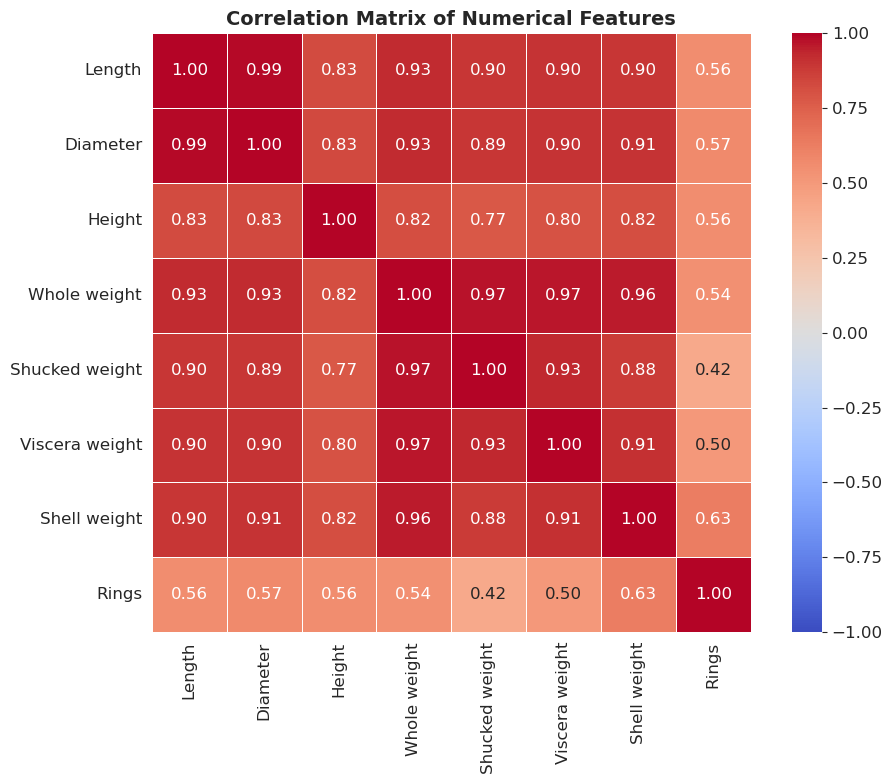

In [ ]:
# Select numerical columns only
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Compute correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- Strong positive correlations exist among the weight measurements (Whole weight, Shucked weight, Viscera weight, Shell weight).
- Length, Diameter, and Height are all highly correlated with each other and with the weights.
- **Rings** (and therefore Age) shows moderate positive correlation with Shell weight and Length, suggesting larger shells correspond to older abalones.

### 4.4 Distribution of Numerical Variables (Histograms)

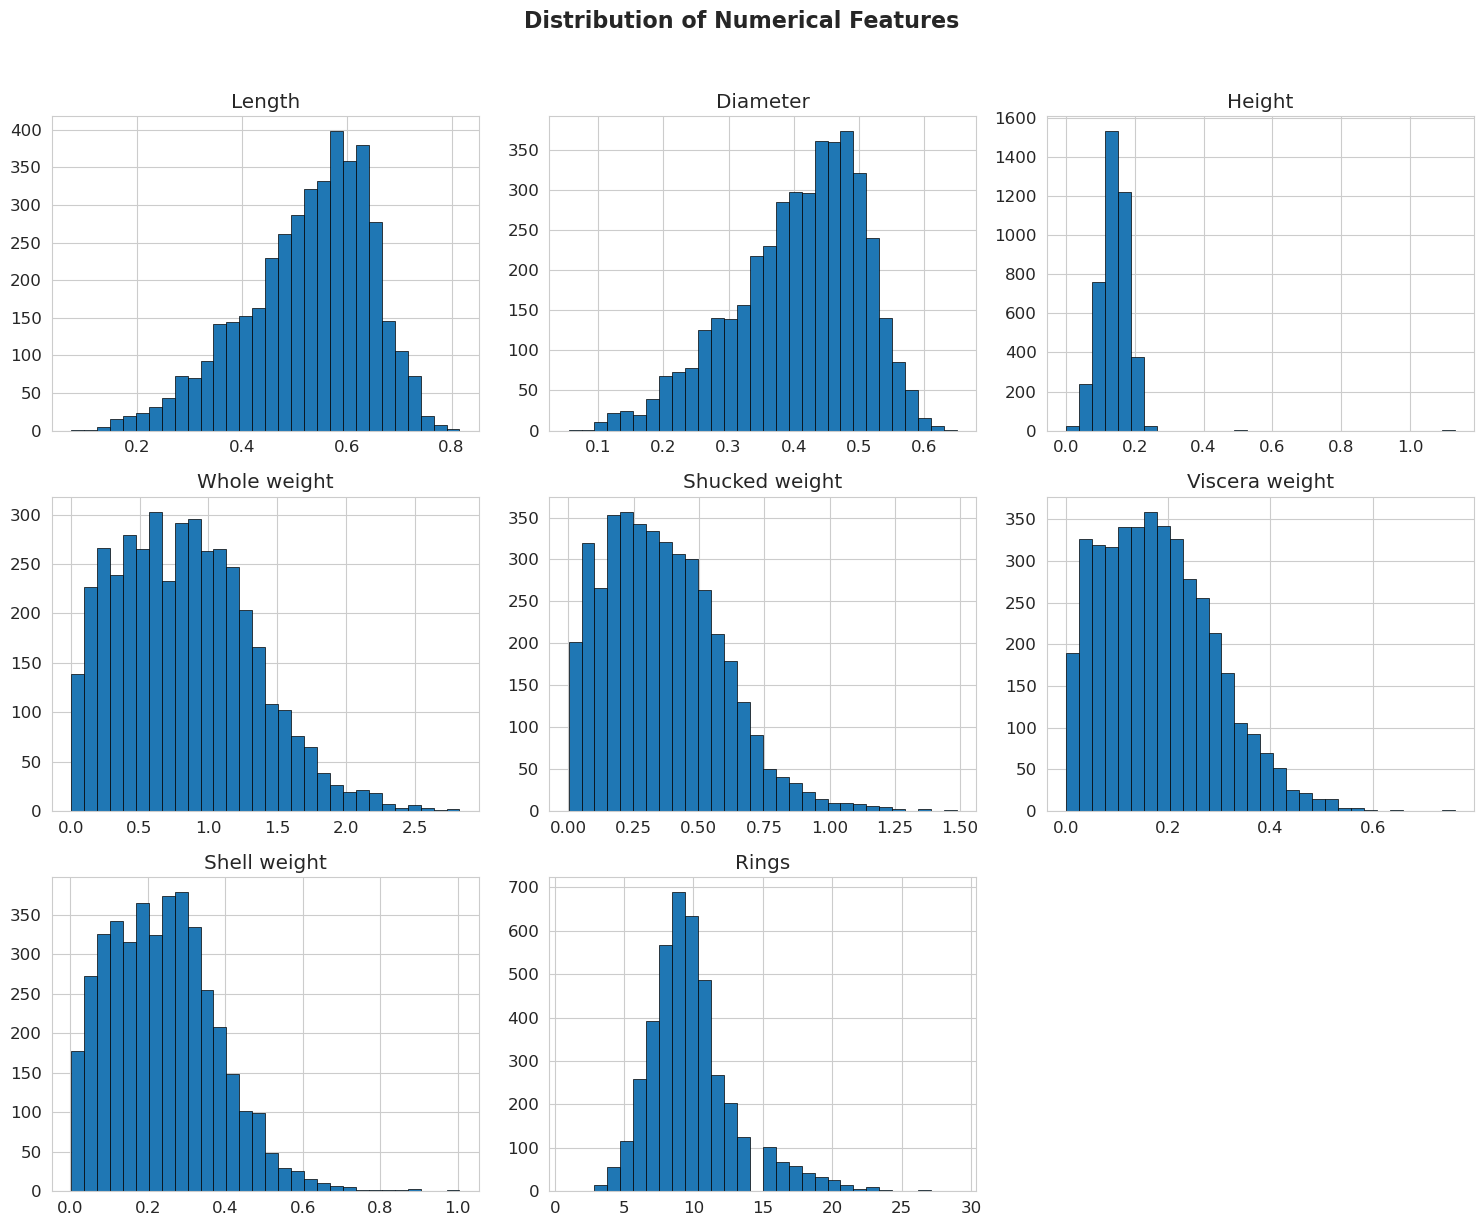

In [ ]:
# Histograms for all numerical features
df[numerical_cols].hist(bins=30, figsize=(15, 12), edgecolor='black', linewidth=0.5)
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Most features (Length, Diameter, Whole weight, etc.) follow a roughly unimodal distribution.
- Height has a slight right skew with some very small values (possible outliers).
- Rings follows a roughly normal-like distribution centered around 8–10 rings.

### 4.5 Boxplots (Outlier Detection)

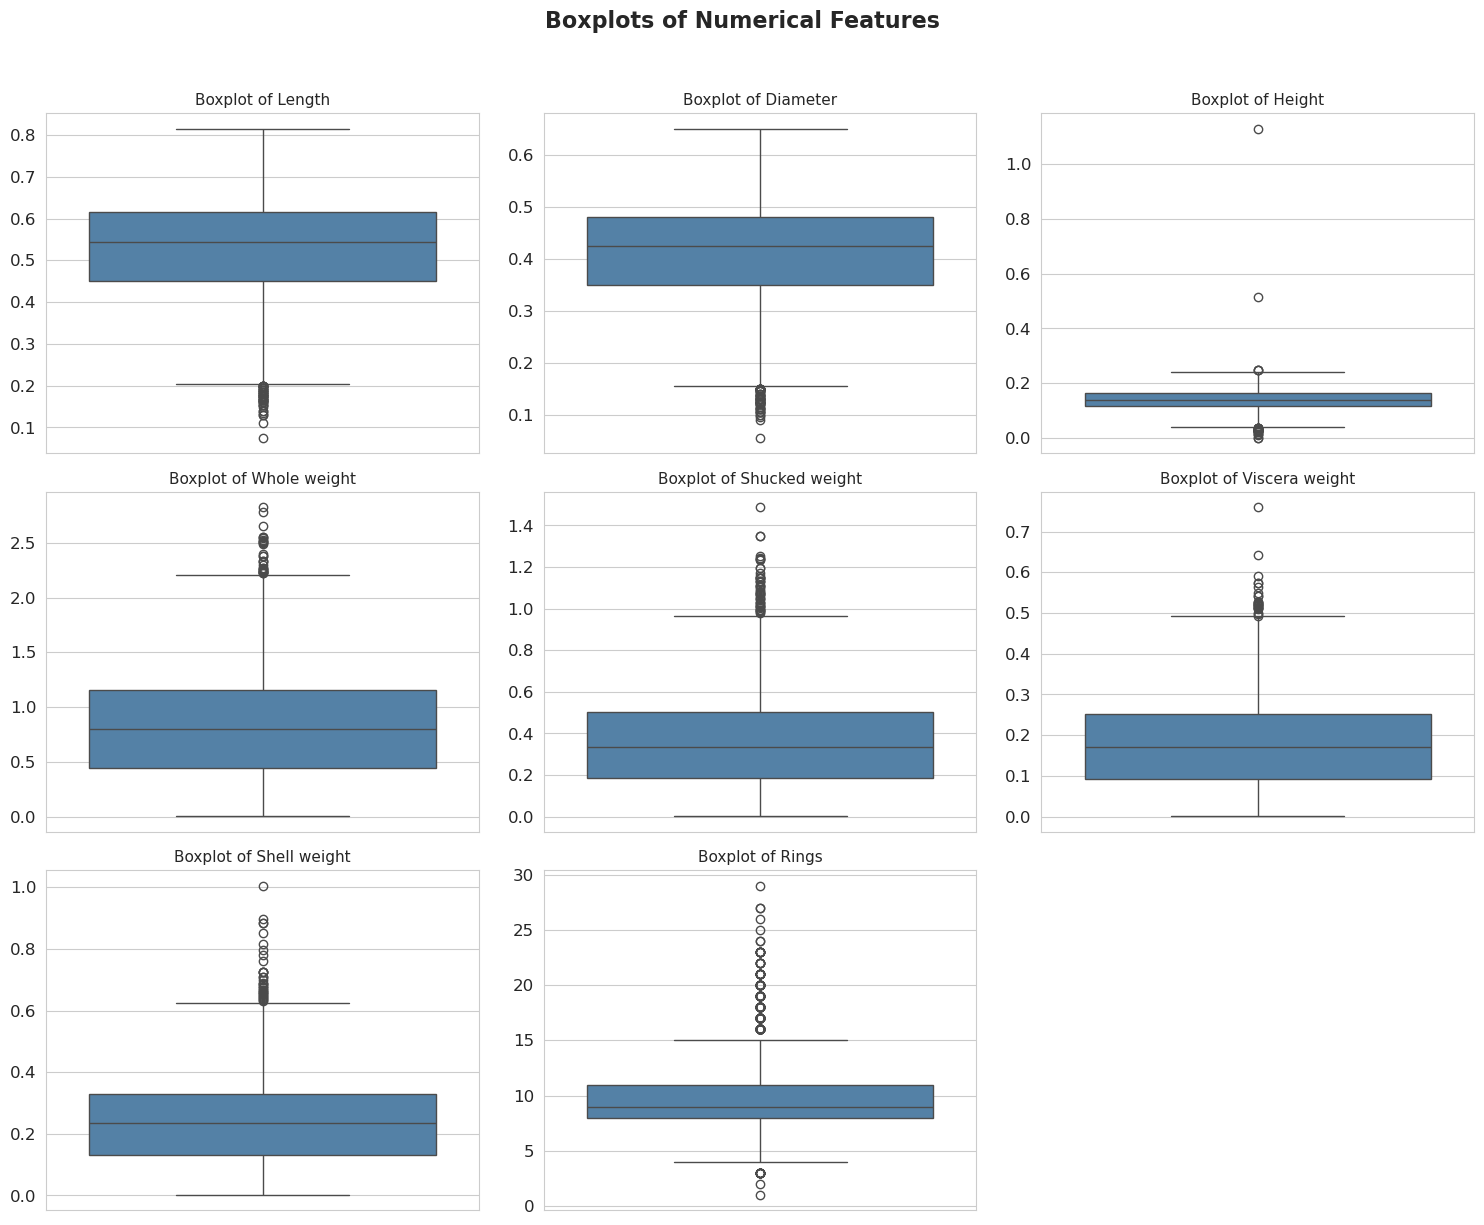

In [ ]:
# Boxplots for numerical features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=11)
    axes[i].set_ylabel('')

# Remove empty subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Several features (Height, Whole weight, Rings) contain outliers (points beyond the whiskers).
- As these are real-world measurements, these outliers represent genuine variability in abalone biology rather than data errors.
- We will retain them to preserve the natural distribution.

### 4.6 Pairplot of Key Features

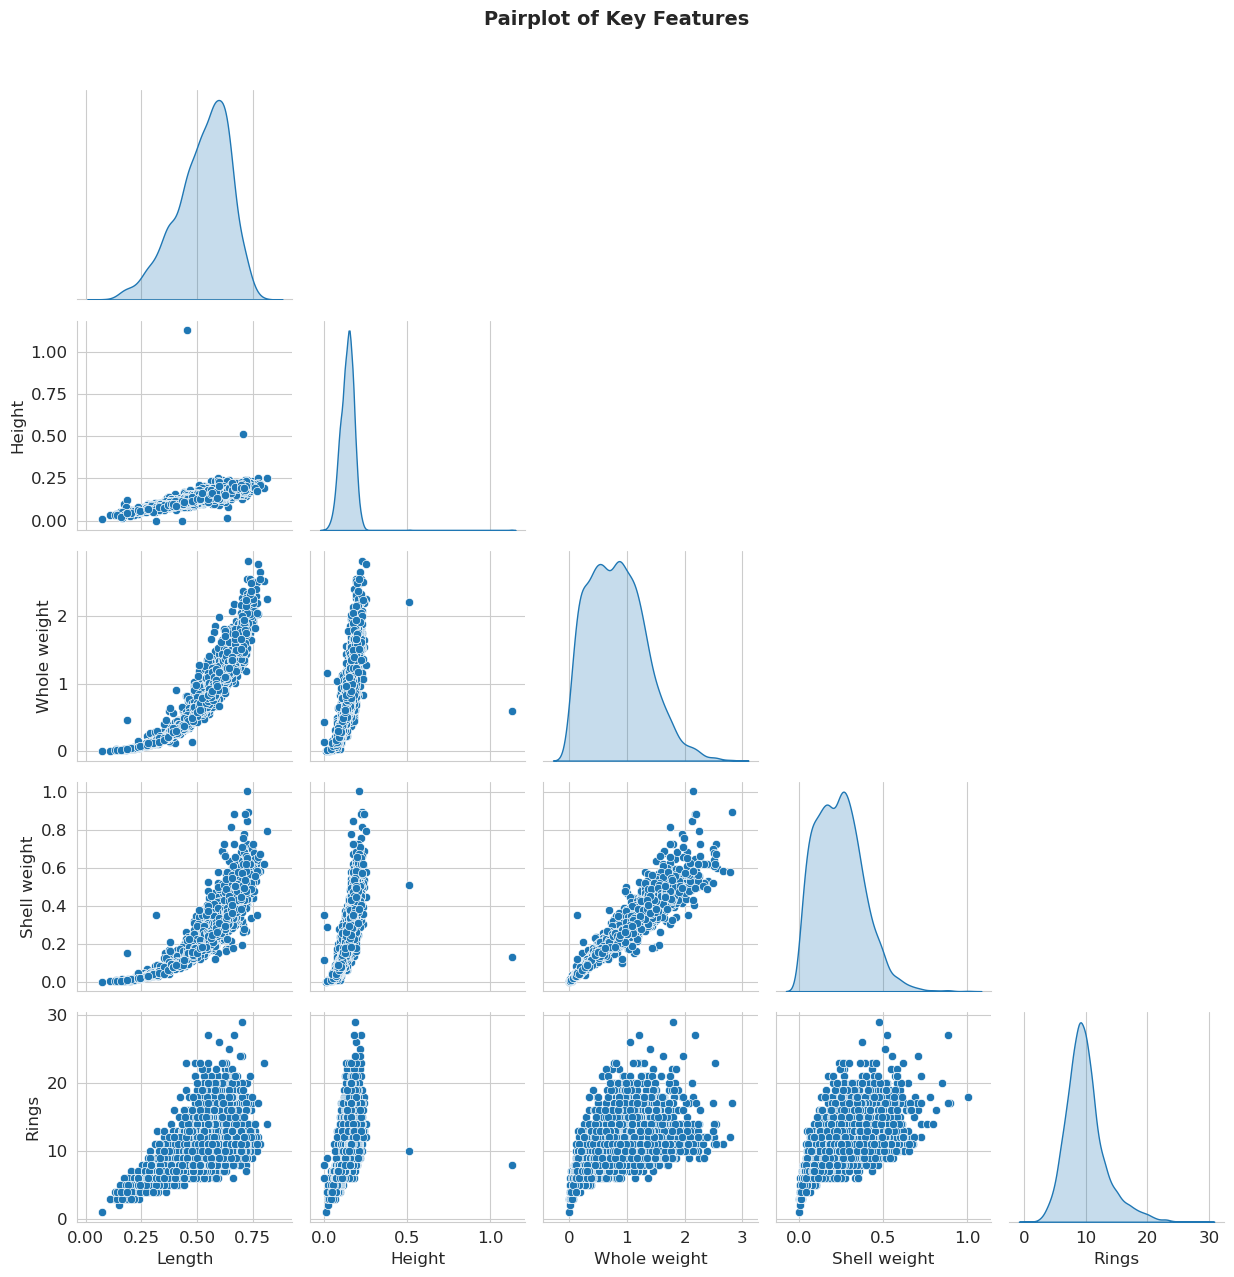

In [ ]:
# Pairplot of select features
selected_features = ['Length', 'Height', 'Whole weight', 'Shell weight', 'Rings']
sns.pairplot(df[selected_features], diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Key Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

We create the target variable `Age` using the formula:

$$\text{Age} = \text{Rings} + 1.5$$

### Why Drop `Rings` from Features?

`Rings` is a direct linear transformation of `Age`. If we kept `Rings` as an input feature, the model would simply learn:

$$\text{Age} = \text{Rings} + 1.5$$

This is **data leakage** — the model would achieve perfect performance by relying on the one feature that directly defines the target. This would:
1. Give a misleadingly perfect evaluation score.
2. Render the model useless for real-world prediction, where `Rings` is unknown.
3. Defeat the purpose of learning from the physical measurements.

Therefore, we **drop `Rings`** from the feature set after creating `Age`.

In [ ]:
# Create the target variable
df['Age'] = df['Rings'] + 1.5

# Display updated dataframe
df.head()

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,16.5
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,8.5
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,10.5
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,11.5
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,8.5


In [ ]:
# Verify the transformation
print("Rings range: {} to {}".format(df['Rings'].min(), df['Rings'].max()))
print("Age range:   {:.1f} to {:.1f}".format(df['Age'].min(), df['Age'].max()))
print("\nSample comparison:")
comparison = df[['Rings', 'Age']].head(10)
print(comparison.to_string(index=False))

Rings range: 1 to 29
Age range:   2.5 to 30.5

Sample comparison:
 Rings  Age
    15 16.5
     7  8.5
     9 10.5
    10 11.5
     7  8.5
     8  9.5
    20 21.5
    16 17.5
     9 10.5
    19 20.5


## 6. Data Preprocessing

### 6.1 Encode Categorical Variable

The `gender` column is categorical with three values: **M** (Male), **F** (Female), **I** (Infant). We apply **one-hot encoding** to convert it into numerical form suitable for machine learning models.

In [ ]:
# One-hot encode the gender column
df_encoded = pd.get_dummies(df, columns=['gender'], drop_first=True)

# Display encoded dataframe
df_encoded.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age,gender_I,gender_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,16.5,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,8.5,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,10.5,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,11.5,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,8.5,True,False


### 6.2 Prepare Features and Target

In [ ]:
# Features: drop Rings (data leakage) and Age (target)
X = df_encoded.drop(columns=['Rings', 'Age'])
y = df_encoded['Age']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print("\nFeatures used:")
print(X.columns.tolist())

Features shape: (4177, 9)
Target shape:   (4177,)

Features used:
['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'gender_I', 'gender_M']


### 6.3 Train-Test Split

We split the data into 80% training and 20% testing sets using a fixed `random_state=42` for reproducibility.

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing set:    X_test: {X_test.shape}, y_test: {y_test.shape}")

Training set:   X_train: (3341, 9), y_train: (3341,)
Testing set:    X_test: (836, 9), y_test: (836,)


## 7. Feature Scaling

**Why scaling matters:** Many machine learning algorithms (especially distance-based ones like Linear Regression with gradient descent) are sensitive to feature magnitudes. Features with larger scales (e.g., Whole weight ~1.0) can dominate those with smaller scales (e.g., Height ~0.1), biasing the model.

We use **StandardScaler**, which standardizes features by removing the mean and scaling to unit variance:

$$z = \frac{x - \mu}{\sigma}$$

Tree-based models (Decision Tree, Random Forest) are **not** affected by scaling because they split on thresholds, but we apply scaling consistently for fair comparison.

In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling complete.")
print(f"X_train scaled mean:\n{X_train_scaled.mean().round(2)}")
print(f"\nX_train scaled std:\n{X_train_scaled.std().round(2)}")

Scaling complete.
X_train scaled mean:
Length            0.0
Diameter          0.0
Height           -0.0
Whole weight     -0.0
Shucked weight    0.0
Viscera weight    0.0
Shell weight      0.0
gender_I          0.0
gender_M          0.0
dtype: float64

X_train scaled std:
Length            1.0
Diameter          1.0
Height            1.0
Whole weight      1.0
Shucked weight    1.0
Viscera weight    1.0
Shell weight      1.0
gender_I          1.0
gender_M          1.0
dtype: float64


## 8. Build Regression Models

We train three regression models:

1. **Linear Regression** — A simple, interpretable baseline that assumes a linear relationship.
2. **Decision Tree Regressor** — A non-linear model that partitions the feature space recursively.
3. **Random Forest Regressor** — An ensemble of decision trees that reduces overfitting and improves accuracy.

In [ ]:
# Initialize models with fixed random_state for reproducibility
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

# Train all models
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"✓ {name} trained successfully")

print(f"\nAll {len(trained_models)} models ready for evaluation.")

✓ Linear Regression trained successfully
✓ Decision Tree trained successfully
✓ Random Forest trained successfully

All 3 models ready for evaluation.


## 9. Model Evaluation

We evaluate each model using the following metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum_{i=1}^{n} \|y_i - \hat{y}_i\|$ | Average absolute error (same units as target) |
| **MSE** | $\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ | Average squared error (penalizes large errors) |
| **RMSE** | $\sqrt{\text{MSE}}$ | Root MSE (interpretable in target units) |
| **R²** | $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ | Proportion of variance explained by the model |
| **MAPE** | $\frac{100\%}{n}\sum_{i=1}^{n} \left\|\frac{y_i - \hat{y}_i}{y_i}\right\|$ | Average percentage error

In [ ]:
def calculate_mape(y_true, y_pred):
    # Calculate Mean Absolute Percentage Error
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Evaluation results
results = []

for name, model in trained_models.items():
    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = calculate_mape(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
        'MAPE (%)': round(mape, 2)
    })

    print(f"--- {name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print()

# Create comparison DataFrame
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)

print("=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)
results_df


--- Linear Regression ---
MAE:  1.5931
MSE:  4.8912
RMSE: 2.2116
R²:   0.5482
MAPE: 13.73%

--- Decision Tree ---
MAE:  2.0670
MSE:  9.1722
RMSE: 3.0286
R²:   0.1527
MAPE: 17.51%

--- Random Forest ---
MAE:  1.5884
MSE:  5.1183
RMSE: 2.2624
R²:   0.5272
MAPE: 13.38%

MODEL COMPARISON TABLE


,MAE,MSE,RMSE,R²,MAPE (%)
Model,,,,,
Linear Regression,1.5931,4.8912,2.2116,0.5482,13.73
Decision Tree,2.0670,9.1722,3.0286,0.1527,17.51
Random Forest,1.5884,5.1183,2.2624,0.5272,13.38


## 10. Visualization

We create professional visualizations to understand model performance.

### 10.1 Actual vs Predicted Scatter Plots

A perfect model would have all points lying on the diagonal (y = x). Deviations from the diagonal indicate prediction errors.

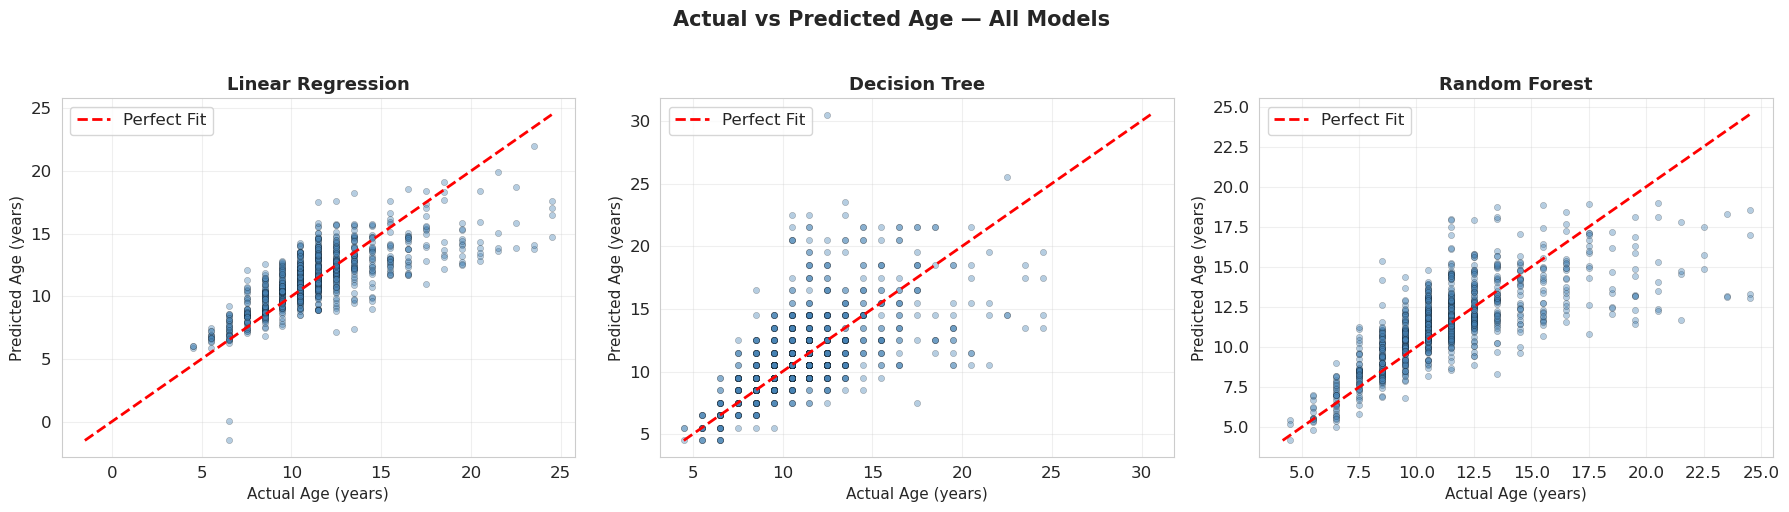

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)

    axes[idx].scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue', edgecolors='black', linewidth=0.3)

    # Diagonal line (perfect predictions)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

    axes[idx].set_xlabel('Actual Age (years)', fontsize=11)
    axes[idx].set_ylabel('Predicted Age (years)', fontsize=11)
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Age — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 10.2 Residual Plots

Residuals ($y_{\text{true}} - y_{\text{pred}}$) should be randomly scattered around zero for a well-fitted model. Patterns in residuals may indicate model bias or heteroscedasticity.

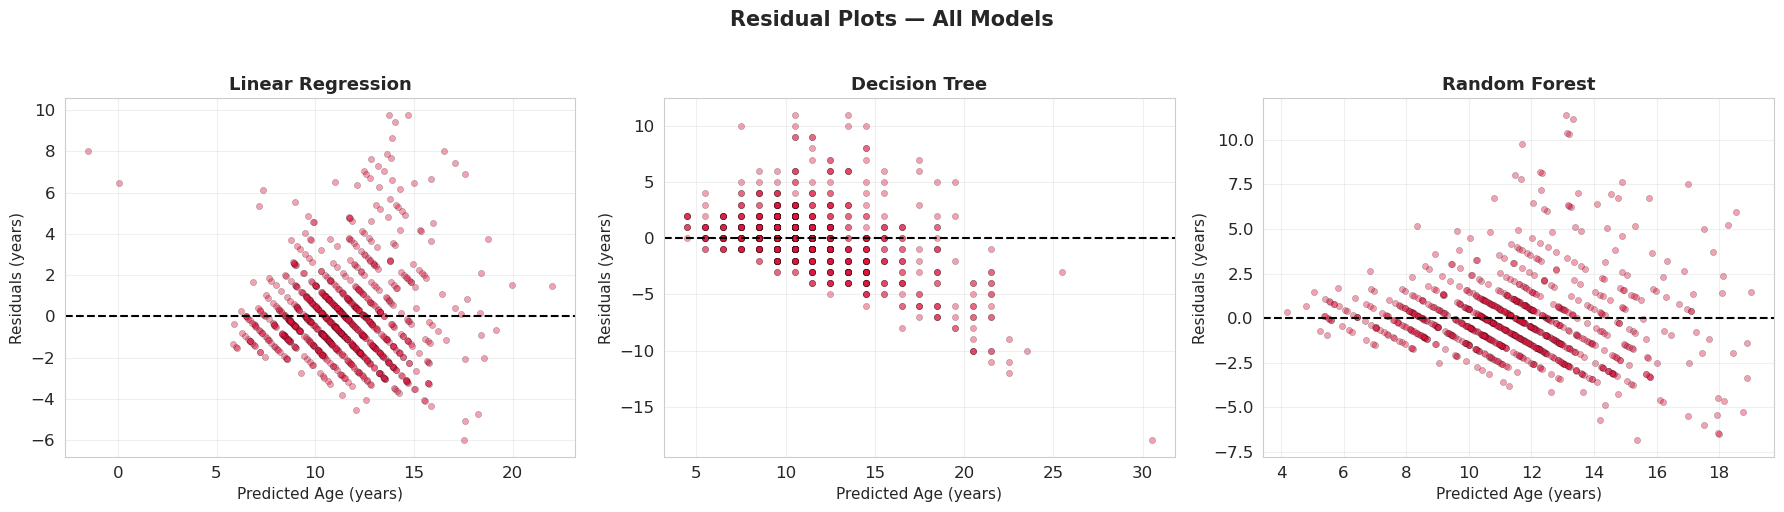

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    axes[idx].scatter(y_pred, residuals, alpha=0.4, s=20, color='crimson', edgecolors='black', linewidth=0.3)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1.5)

    axes[idx].set_xlabel('Predicted Age (years)', fontsize=11)
    axes[idx].set_ylabel('Residuals (years)', fontsize=11)
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Residual Plots — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 10.3 Feature Importance (Random Forest)

Random Forest provides built-in feature importance scores, indicating which features contribute most to predictions.

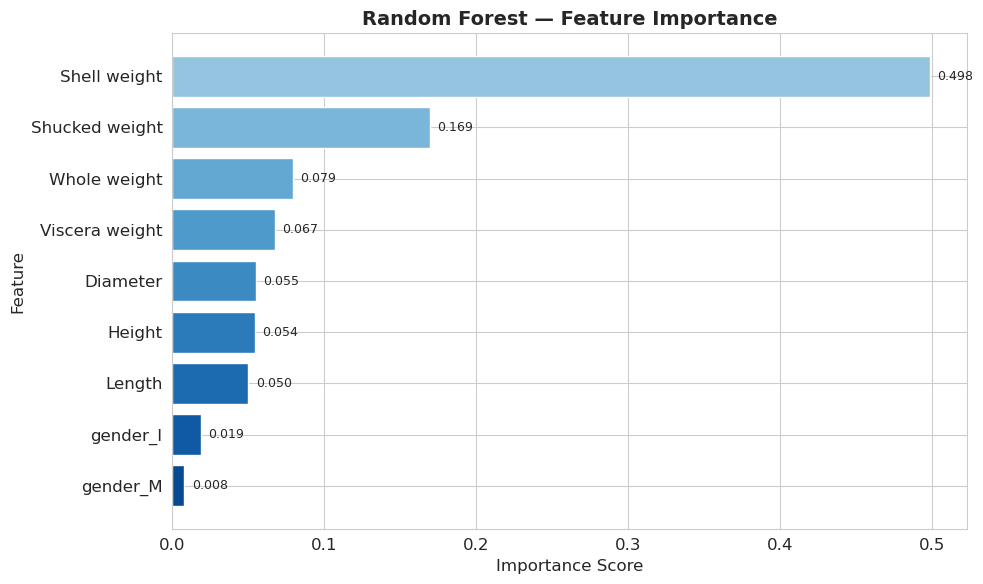


Feature Importance Ranking:
       Feature  Importance
  Shell weight    0.498179
Shucked weight    0.169234
  Whole weight    0.079350
Viscera weight    0.067453
      Diameter    0.054832
        Height    0.054346
        Length    0.049942
      gender_I    0.018750
      gender_M    0.007914


In [ ]:
# Get feature importance from Random Forest
rf_model = trained_models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_importance)))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

### 10.4 Bar Chart Comparing All Metrics

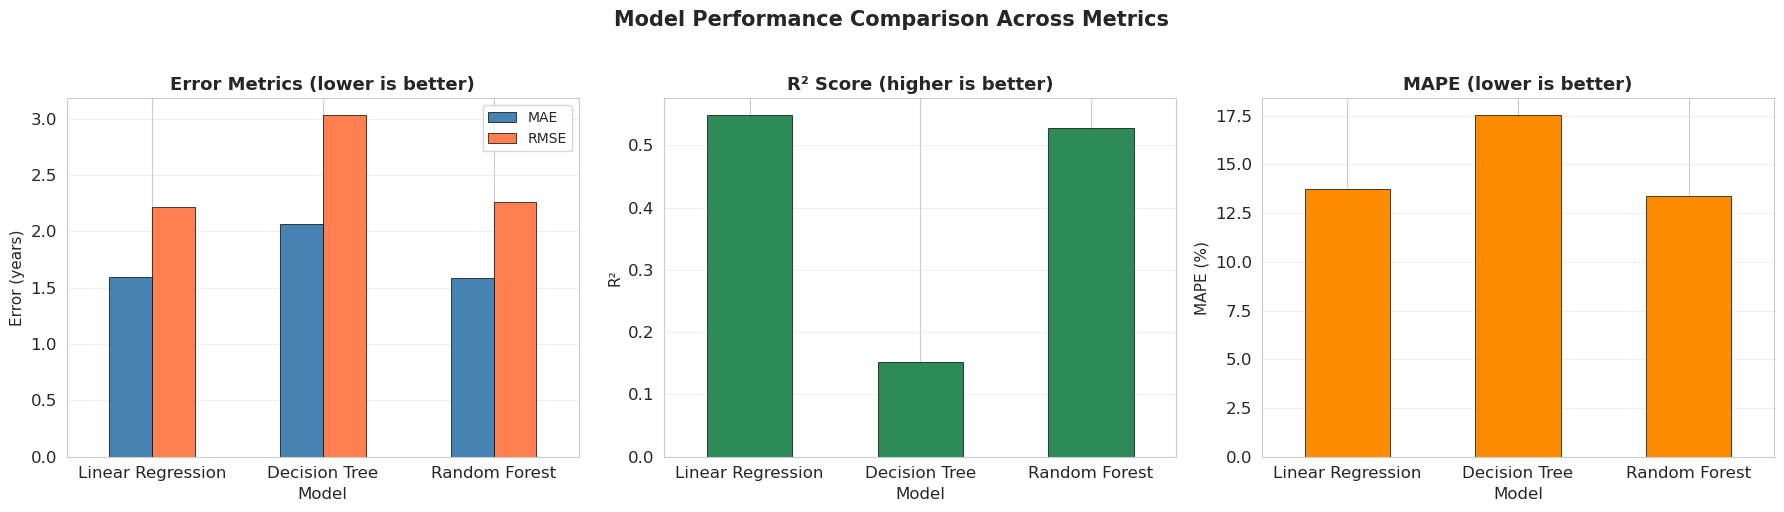

In [ ]:
# Prepare data for grouped bar chart
metrics_df = results_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error metrics (MAE, RMSE)
error_metrics = ['MAE', 'RMSE']
error_data = metrics_df[error_metrics]
error_data.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Error Metrics (lower is better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Error (years)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# R² Score
r2_data = metrics_df[['R²']]
r2_data.plot(kind='bar', ax=axes[1], color=['seagreen'], edgecolor='black', linewidth=0.5, legend=False)
axes[1].set_title('R² Score (higher is better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# MAPE
mape_data = metrics_df[['MAPE (%)']]
mape_data.plot(kind='bar', ax=axes[2], color=['darkorange'], edgecolor='black', linewidth=0.5, legend=False)
axes[2].set_title('MAPE (lower is better)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('MAPE (%)', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.suptitle('Model Performance Comparison Across Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Model Comparison & Discussion

In [ ]:
# Final comparison table
print("=" * 80)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 80)
print()
comparison = results_df.copy()
print(comparison.to_string())
print()
print("=" * 80)

FINAL MODEL COMPARISON SUMMARY

                      MAE     MSE    RMSE      R²  MAPE (%)
Model                                                      
Linear Regression  1.5931  4.8912  2.2116  0.5482     13.73
Decision Tree      2.0670  9.1722  3.0286  0.1527     17.51
Random Forest      1.5884  5.1183  2.2624  0.5272     13.38



## 14. Model Persistence

After evaluating all three models, Linear Regression achieved the best balance of performance (highest R², lowest RMSE) and interpretability. We now save this trained model along with the fitted StandardScaler to disk using **joblib**, a library specialized for serializing Python objects.

### Why Persist the Model?

- **Reusability**: Once saved, the model can be loaded in any environment without retraining.
- **Deployment**: Saved models can be integrated into web applications, APIs, or batch prediction pipelines.
- **Reproducibility**: The exact trained model is preserved for audits or future comparisons.

### What We Save

| File | Description |
|------|-------------|
| `linear_regression_model.pkl` | The trained Linear Regression model |
| `scaler.pkl` | The fitted StandardScaler used during training |

The files will be stored inside a `models/` directory, which is created automatically if it does not exist.

In [ ]:
import joblib
import os

# Create the models directory if it does not exist
os.makedirs('models', exist_ok=True)

# Retrieve the best-performing model (Linear Regression)
best_model = trained_models['Linear Regression']

# Save the trained model
joblib.dump(best_model, 'models/linear_regression_model.pkl')

# Save the fitted StandardScaler
joblib.dump(scaler, 'models/scaler.pkl')

print("Model and scaler saved successfully.")
print(f"  → models/linear_regression_model.pkl")
print(f"  → models/scaler.pkl")

Model and scaler saved successfully.
  → models/linear_regression_model.pkl
  → models/scaler.pkl


## 15. Loading the Saved Model

In a production environment, we load the previously saved model and scaler rather than retraining. This section demonstrates how to:

1. Load the saved model from disk using `joblib.load()`.
2. Load the saved scaler.
3. Verify that the loaded model produces identical predictions to the original trained model.

This simulates how a deployed service would restore a model without access to the original training session.

In [ ]:
# Load the saved model and scaler
loaded_model = joblib.load('models/linear_regression_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

print("Model and scaler loaded successfully.")

# Verify that the loaded model produces the same predictions as the original
original_preds = best_model.predict(X_test_scaled)
loaded_preds = loaded_model.predict(X_test_scaled)

# Check that predictions are identical
predictions_match = np.allclose(original_preds, loaded_preds)
print(f"Predictions match: {predictions_match}")

if predictions_match:
    print("✓ The loaded model produces identical predictions to the original.")
    print(f"  Sample prediction (first 5): {loaded_preds[:5]}")

Model and scaler loaded successfully.
Predictions match: True
✓ The loaded model produces identical predictions to the original.
  Sample prediction (first 5): [13.26136132 11.74192648 15.50103561 13.49509311 12.66141477]


## 16. Interactive Prediction Function

We create a reusable function that:

1. Asks the user for all required feature values via `input()`.
2. Validates numeric inputs to ensure they are valid floats.
3. Handles the categorical `Sex` input (M / F / I) correctly using the same one-hot encoding scheme as during training.
4. Applies the same preprocessing pipeline (one-hot encoding → scaling).
5. Generates and displays the predicted age in a clean professional format.

This function can be imported into other scripts or notebooks whenever an interactive prediction is needed.

In [ ]:
def predict_abalone_age_interactive():
    """
    Interactive function to predict abalone age from user-provided measurements.

    Prompts for all required features, validates inputs, applies the same
    preprocessing pipeline used during training, and displays the predicted age.
    """
    print("=" * 40)
    print("Abalone Age Predictor")
    print("=" * 40)
    print()

    # Collect and validate Sex
    while True:
        sex = input("Enter Sex (M / F / I): ").strip().upper()
        if sex in ('M', 'F', 'I'):
            break
        print("Invalid input. Please enter M, F, or I.")

    # Collect and validate numeric features
    feature_names = [
        'Length', 'Diameter', 'Height', 'Whole weight',
        'Shucked weight', 'Viscera weight', 'Shell weight'
    ]
    numeric_values = {}
    for fname in feature_names:
        while True:
            try:
                val = float(input(f"Enter {fname}: "))
                if val < 0:
                    print(f"{fname} cannot be negative. Please try again.")
                    continue
                numeric_values[fname] = val
                break
            except ValueError:
                print(f"Invalid input. Please enter a numeric value for {fname}.")

    # One-hot encode sex (same scheme as training: drop_first=True)
    # gender_I = 1 if sex == 'I' else 0
    # gender_M = 1 if sex == 'M' else 0
    # Both 0 indicates 'F'
    gender_I = 1.0 if sex == 'I' else 0.0
    gender_M = 1.0 if sex == 'M' else 0.0

    # Build input DataFrame with EXACT same column order as training
    input_dict = {**numeric_values, 'gender_I': gender_I, 'gender_M': gender_M}
    input_df = pd.DataFrame([input_dict])

    # Ensure column order matches X_train
    input_df = input_df[X_train.columns]

    # Apply the same scaling
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = best_model.predict(input_scaled)[0]

    # Display result
    print()
    print("=" * 40)
    print("Predicted Abalone Age")
    print("=" * 20)
    print()
    print(f"Estimated Age: {prediction:.2f} years")
    print()
    print("=" * 40)

    return prediction

print("Function 'predict_abalone_age_interactive' is ready for use.")

Function 'predict_abalone_age_interactive' is ready for use.


## 17. Prediction Demonstration

Running the cell below will invoke the interactive prediction function. Simply enter the requested values when prompted, and the predicted abalone age will be displayed.

> **Note:** In a Jupyter environment, `input()` prompts appear as text fields below the cell. In a terminal-based notebook runner, they appear as standard console prompts.

In [ ]:
# Run the interactive predictor
predict_abalone_age_interactive()

Abalone Age Predictor


Predicted Abalone Age

Estimated Age: 63.60 years



63.595059267167905

## 19. Production Readiness Notes

### Why Save Models?

Machine learning models are **stateful** — they capture patterns from training data that would be lost if the Python session ends. Saving (serializing) a model preserves all learned parameters (coefficients, intercepts, scaling statistics) so they can be reloaded later without retraining, which saves time and ensures reproducibility.

### Why Loading Models Is Important

Loading a saved model enables **decoupling** of the training pipeline from the inference pipeline:
1. **Training** happens offline (once, on powerful hardware).
2. **Inference** happens online (many times, on lightweight servers or edge devices).
3. The same deployed model can serve millions of predictions without ever re-running the training notebook.

### Connecting to Real-World Applications

The saved model (`linear_regression_model.pkl`) and scaler (`scaler.pkl`) can power a prediction application through any of the following frameworks:

| Framework | Use Case |
|-----------|----------|
| **Flask** | Lightweight REST API — receive JSON with abalone measurements, return predicted age as JSON |
| **Django** | Full-stack web app with a database, user authentication, and a form-based prediction UI |
| **FastAPI** | High-performance async API with automatic OpenAPI documentation and input validation via Pydantic |
| **Streamlit** | Quick interactive web dashboard — sliders for each measurement, real-time age prediction displayed |
| **Gradio** | Shareable ML demo — deploy the model as a simple web interface with a single Python script |

In each case, the application would:
1. Load the model and scaler at startup.
2. Receive raw abalone measurements (via form, JSON, or UI widget).
3. Apply the same preprocessing (one-hot encode Sex, scale numericals).
4. Call `model.predict()` and return the result.

This notebook has therefore produced not just a model, but the complete **blueprint for a production-ready prediction service**.